In [2]:
import numpy
import matplotlib
import sklearn

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Set plots to be PDF-friendly
plt.rcParams["figure.figsize"] = (6,4)
plt.rcParams["figure.dpi"] = 120

In [4]:
# Load Iris dataset
iris = datasets.load_iris()
X = iris.data[:, 2:4]  # petal length & width
y = iris.target

# Only use two classes (Setosa and Versicolor)
X = X[y != 2]
y = y[y != 2]

print("Dataset shape:", X.shape)
print("Classes:", np.unique(y))

Dataset shape: (100, 2)
Classes: [0 1]


In [5]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
def plot_decision_boundary(model, X, y, title):
    # Setup grid for plotting
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    # Predict over grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Create the plot
    plt.figure(figsize=(6, 4))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')  # Color-blind friendly palette
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='viridis', edgecolors='k')
    
    # Accessibility: Clear labels and titles
    plt.xlabel('Petal Length (Standardized)')
    plt.ylabel('Petal Width (Standardized)')
    plt.title(title)
    
    # Add a legend for clarity
    handles, _ = scatter.legend_elements()
    plt.legend(handles, ['Setosa', 'Versicolor'], title="Classes")

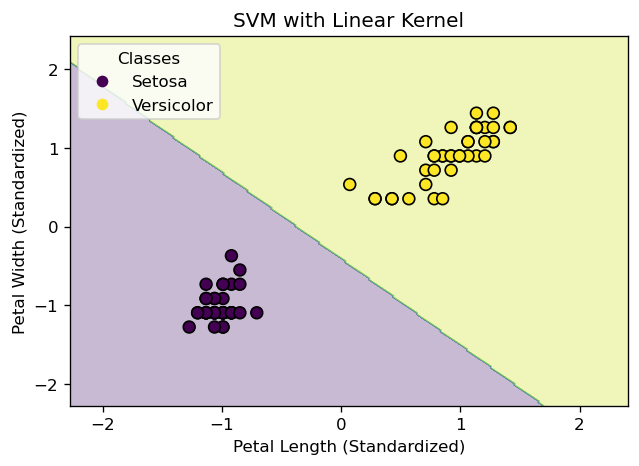

In [7]:
linear_model = SVC(kernel='linear', C=1.0)
linear_model.fit(X_train, y_train)
plot_decision_boundary(linear_model, X_train, y_train, "SVM with Linear Kernel")

> **Visual Description:** This plot illustrates a **Linear SVM** decision boundary. It shows a perfectly straight diagonal line separating two clusters of data points: purple dots (Setosa) in the bottom-left and yellow dots (Versicolor) in the top-right. The background is shaded in two distinct colors to show the decision regions, and the linear boundary clearly maximizes the margin between the two classes.

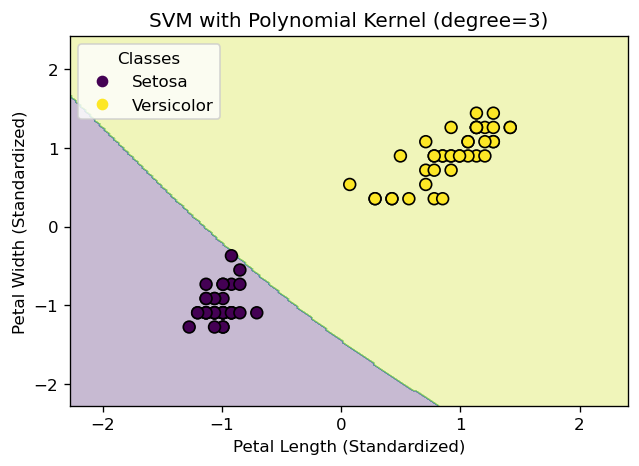

In [8]:
poly_model = SVC(kernel='poly', degree=3, C=1.0)
poly_model.fit(X_train, y_train)
plot_decision_boundary(poly_model, X_train, y_train, "SVM with Polynomial Kernel (degree=3)")

> **Visual Description:** This plot displays the **Polynomial SVM** decision boundary. The boundary is no longer a straight line but a smooth, slight curve that bends to accommodate the data distribution. The shading indicates how the polynomial transformation allows the model to separate the two classes (purple and yellow) in a non-linear fashion while maintaining a clear decision margin.

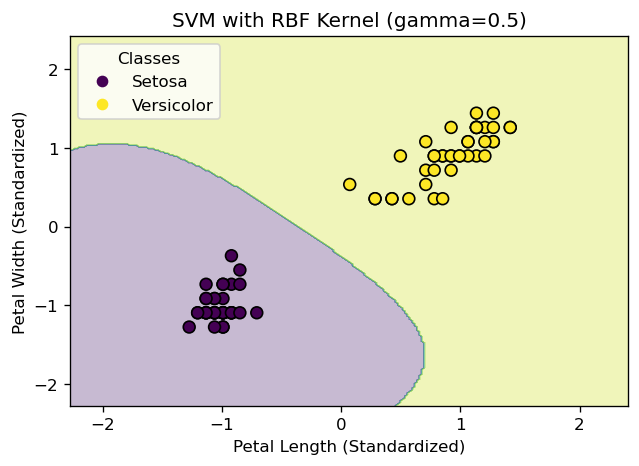

In [9]:
rbf_model = SVC(kernel='rbf', C=1.0, gamma=0.5)
rbf_model.fit(X_train, y_train)
plot_decision_boundary(rbf_model, X_train, y_train, "SVM with RBF Kernel (gamma=0.5)")

> **Visual Description:** This plot shows the **RBF (Gaussian) Kernel** decision boundary. The boundary is highly flexible and appears as a sophisticated, non-linear curve. The shaded decision regions wrap closely around the clusters of purple and yellow data points, demonstrating the RBF kernel's ability to handle complex, overlapping, or non-linear spatial relationships between classes.

Text(0.5, 0.92, '3D view of RBF kernel decision function')

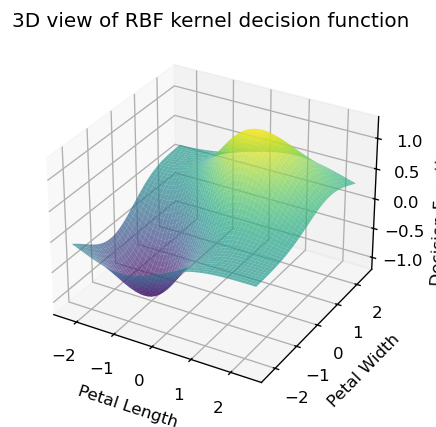

In [10]:
xx, yy = np.meshgrid(np.linspace(X_train[:,0].min()-1, X_train[:,0].max()+1, 50),
                     np.linspace(X_train[:,1].min()-1, X_train[:,1].max()+1, 50))
Z = rbf_model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xx, yy, Z, cmap=cm.viridis, alpha=0.7)
ax.set_xlabel('Petal Length')
ax.set_ylabel('Petal Width')
ax.set_zlabel('Decision Function Value')
plt.title("3D view of RBF kernel decision function")

> **Visual Description:** This is a **3D surface plot** representing the decision function of the **RBF (Gaussian) Kernel**. The X and Y axes represent 'Petal Length' and 'Petal Width' respectively, while the vertical Z-axis represents the 'Decision Function Value'. The plot shows a curved, "mountain-like" surface using the color-blind friendly 'viridis' colormap. The "peaks" and "valleys" of the surface illustrate how the RBF kernel assigns high or low probabilities to different regions of the feature space, creating a flexible, non-linear boundary where the surface crosses the zero-plane.

<Figure size 1200x480 with 0 Axes>

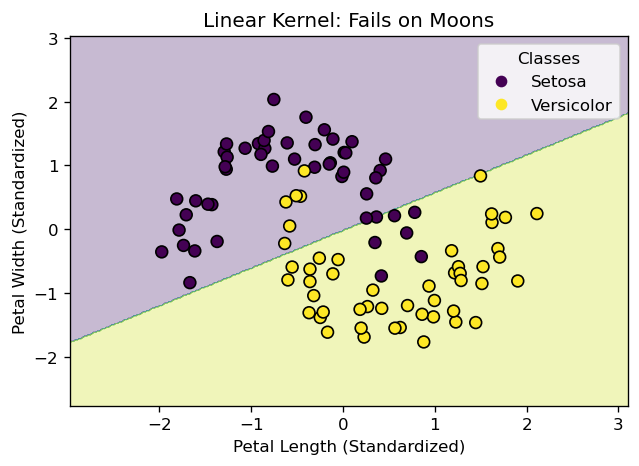

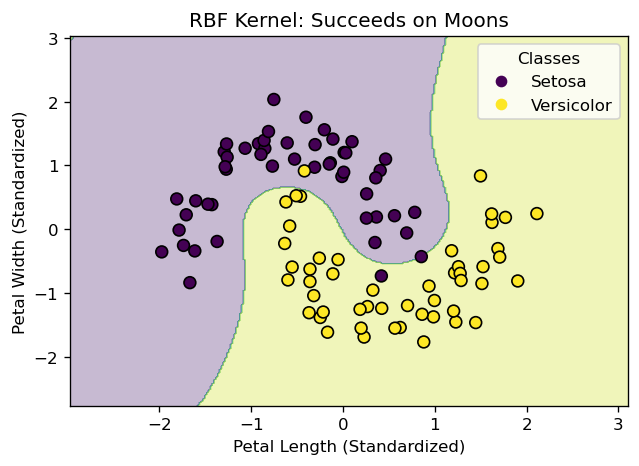

In [11]:
from sklearn.datasets import make_moons

# 1. Generate non-linear data
X_moon, y_moon = make_moons(n_samples=100, noise=0.15, random_state=42)
X_moon = scaler.fit_transform(X_moon)

# 2. Compare Linear vs RBF
linear_moon = SVC(kernel='linear').fit(X_moon, y_moon)
rbf_moon = SVC(kernel='rbf', gamma=1).fit(X_moon, y_moon)

# 3. Plotting comparison
plt.figure(figsize=(10, 4))
plot_decision_boundary(linear_moon, X_moon, y_moon, "Linear Kernel: Fails on Moons")
plot_decision_boundary(rbf_moon, X_moon, y_moon, "RBF Kernel: Succeeds on Moons")

In [12]:
from sklearn.metrics import accuracy_score, classification_report

# list of models for iteration
models = [linear_model, poly_model, rbf_model]
model_names = ["Linear Kernel", "Polynomial (d=3)", "RBF Kernel"]

print("Evaluation Metrics for Iris Dataset:")
print("-" * 40)

for name, model in zip(model_names, models):
    # Predict on the test set you created in Cell 22
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name:20} | Test Accuracy: {acc:.2%}")

# Detailed report for the best performing model
print("\nDetailed Classification Report (RBF):")
print(classification_report(y_test, rbf_model.predict(X_test), target_names=['Setosa', 'Versicolor']))

Evaluation Metrics for Iris Dataset:
----------------------------------------
Linear Kernel        | Test Accuracy: 100.00%
Polynomial (d=3)     | Test Accuracy: 100.00%
RBF Kernel           | Test Accuracy: 100.00%

Detailed Classification Report (RBF):
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        12
  Versicolor       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

